In [37]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [38]:
df = pd.read_csv("C:/Users/bingi/Downloads/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [40]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 5


In [41]:
def rename_columns(df):
    return df.rename(columns = {
        "CustomerID": "Customer_ID",
        "Annual Income (k$)": "Annual_Income"
    })
df = rename_columns(df)
df.head()

,Customer_ID,Gender,Age,Annual_Income,Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [42]:
df.nunique()

Customer_ID               200
Gender                      2
Age                        51
Annual_Income              64
Spending Score (1-100)     84
dtype: int64

In [43]:
df.isnull().sum()

Customer_ID               0
Gender                    0
Age                       0
Annual_Income             0
Spending Score (1-100)    0
dtype: int64

In [44]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

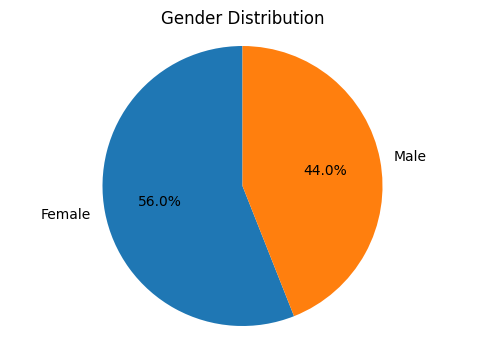

In [45]:
gender_status = df['Gender'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(gender_status, labels=gender_status.index , autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()  

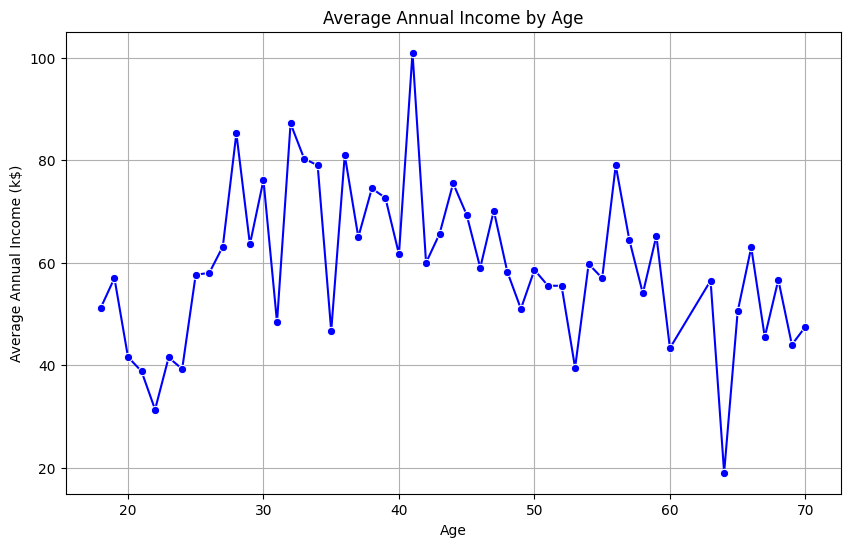

In [46]:
Age_by_Income = df.groupby('Age')['Annual_Income'].mean().reset_index()

plt.figure(figsize = (10,6))
sns.lineplot(data = Age_by_Income,
             x = 'Age',
             y = 'Annual_Income',
             marker = 'o',
             color = 'blue')
plt.title('Average Annual Income by Age')
plt.xlabel('Age')
plt.ylabel('Average Annual Income (k$)')
plt.grid()
plt.show()

In [55]:
gender_income = df.groupby('Gender')['Annual_Income'].mean().reset_index()

fig = px.bar(gender_income,
             x='Gender',
             y='Annual_Income',
             color='Gender',
             title='Average Annual Income by Gender')

fig.update_layout(
    xaxis_title='Gender',
    yaxis_title='Average Annual Income (k$)',
    title_font=dict(size=18, family='Arial', color='black'),
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(showgrid=True, gridcolor='lightgrey', gridwidth=0.5),
    yaxis=dict(showgrid=True, gridcolor='lightgrey', gridwidth=0.5)
)

fig.show()


Text(0, 0.5, 'Total Spending')

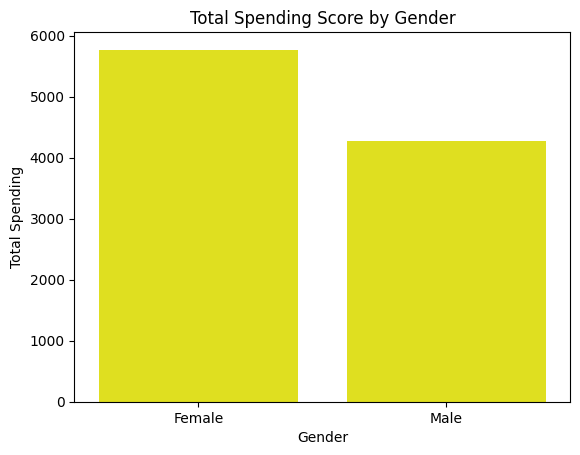

In [61]:
gender_by_spending = df.groupby('Gender')['Spending Score (1-100)'].sum().reset_index()

fig = sns.barplot(data = gender_by_spending,
                      x = 'Gender',
                      y = 'Spending Score (1-100)',
                      color = 'yellow')
plt.title('Total Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Spending')

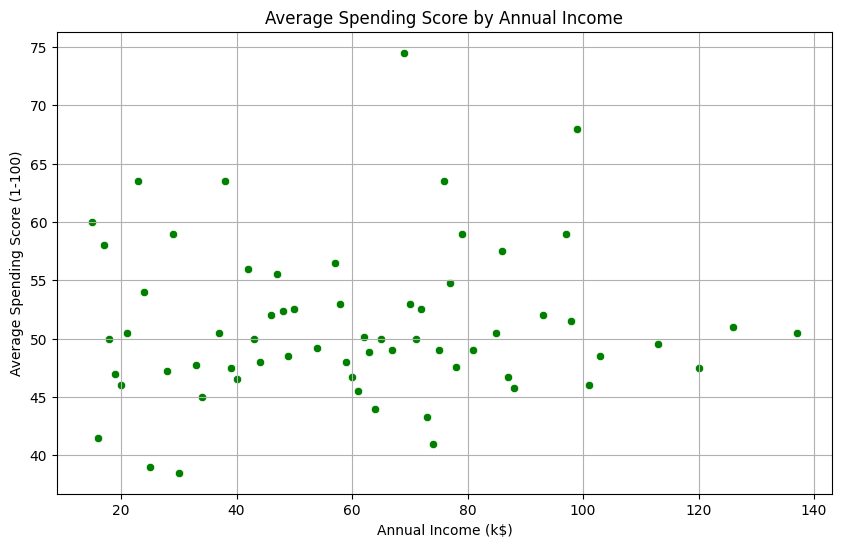

In [63]:
income_by_spending = df.groupby('Annual_Income')['Spending Score (1-100)'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(data=income_by_spending, x='Annual_Income', y='Spending Score (1-100)', color='green')
plt.title('Average Spending Score by Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Average Spending Score (1-100)')
plt.grid()
plt.show()